<a href="https://colab.research.google.com/github/shhjosh02/Financial-Forecast-ML/blob/main/notebooks/03_LSTM_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
✅ Colab conectado. Directorio actual: /content/drive/MyDrive/Proyecto_IA/notebooks
✅ Dataset cargado: 18693 filas
📅 Rango: 2013-02-08 00:00:00 a 2018-02-07 00:00:00

📊 DISTRIBUCIÓN DE CLASES
Label
1    10286
0     8407
Name: count, dtype: int64

✅ Train: 14954 | Test: 3739

⚖️ Class weights: {0: np.float64(1.1070476754515843), 1: np.float64(0.911829268292683)}

🚀 ENTRENANDO LSTM HÍBRIDA
Epoch 1/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9768 - loss: 0.4576 - val_accuracy: 1.0000 - val_loss: 0.0908
Epoch 2/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 1.0000 - loss: 0.0657 - val_accuracy: 1.0000 - val_loss: 0.0394
Epoch 3/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 1.0000 - loss: 0.0397 - val_accuracy: 1.0000 - val_loss: 0.0283
Epoch 4/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 1.0000 - loss: 0.0308 - val_accuracy: 1.0000 - val_loss: 0.0216
Epoch 5/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 1

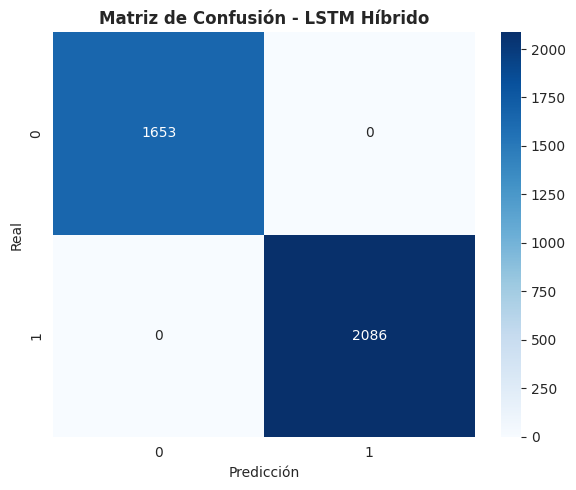

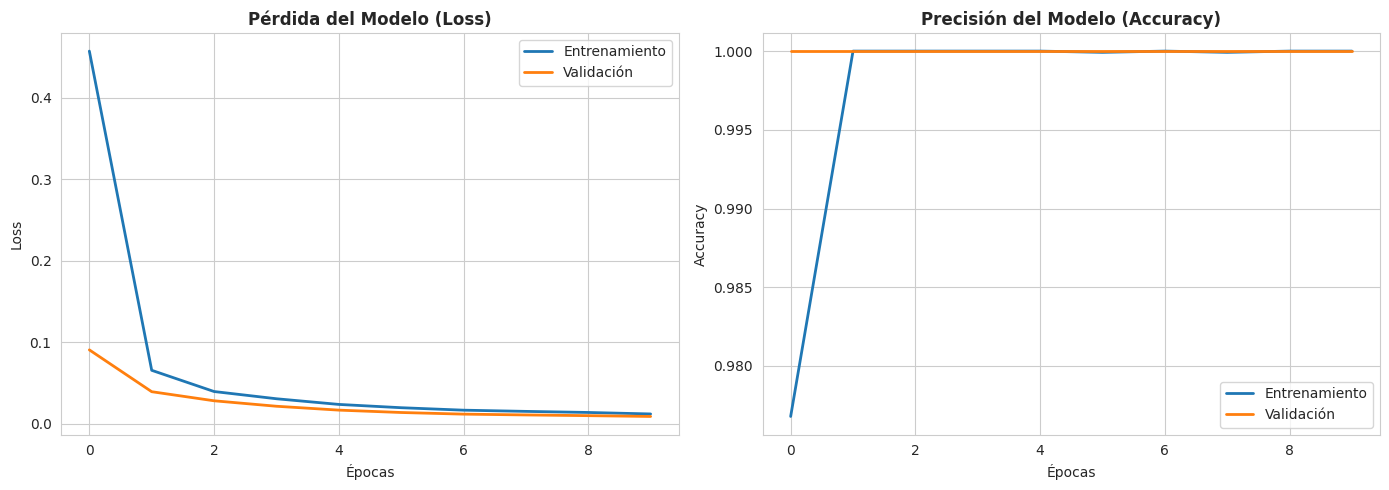


✅ LSTM Ejecutado y Gráficos Generados Exitosamente.


In [1]:
# =========================================================
# BLOQUE DE PORTABILIDAD: Colab + Drive + Local
# =========================================================
import os
import sys

EN_COLAB = 'google.colab' in sys.modules
CARPETA_DRIVE = 'Proyecto_IA'

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir(f'/content/drive/MyDrive/{CARPETA_DRIVE}/notebooks')
    print(f"✅ Colab conectado. Directorio actual: {os.getcwd()}")

os.makedirs('../outputs/graficos', exist_ok=True)

# -*- coding: utf-8 -*-
"""
MODELO LSTM HÍBRIDO (CORREGIDO)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# =========================================================
# 2. CARGAR DATOS
# =========================================================
df = pd.read_csv('../data/dataset_final_para_modelos(modificado).csv', sep=';', encoding='latin-1')

if 'ï»¿date' in df.columns:
    df.rename(columns={'ï»¿date': 'date'}, inplace=True)

# Convertir fecha y ordenar cronológicamente
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', errors='coerce')
df = df.sort_values('date').reset_index(drop=True)

print(f"✅ Dataset cargado: {df.shape[0]} filas")
print(f"📅 Rango: {df['date'].min()} a {df['date'].max()}")

# =========================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS
# =========================================================
df['daily_return'] = (df['close'] - df['open']) / df['open']
df['intraday_volatility'] = (df['high'] - df['low']) / df['close']
df['volume_scaled'] = df['volume'] / df['volume'].max()
df['price_range'] = df['high'] - df['low']

# =========================================================
# 4. PREPARAR TEXTO
# =========================================================
headlines = df['Headline_esp'].astype(str).values
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(headlines)
X_text = pad_sequences(tokenizer.texts_to_sequences(headlines), maxlen=20, padding='post', truncating='post')

# =========================================================
# 5. NUMÉRICOS Y LABELS
# =========================================================
scaler = StandardScaler()
X_num = scaler.fit_transform(df[['daily_return', 'intraday_volatility', 'volume_scaled', 'price_range']].fillna(0).values)
y = df['Label'].values

print("\n" + "="*60)
print("📊 DISTRIBUCIÓN DE CLASES")
print("="*60)
print(df['Label'].value_counts())

# =========================================================
# 6. DIVIDIR CRONOLÓGICAMENTE
# =========================================================
split_idx = int(len(df) * 0.8)

X_text_train = X_text[:split_idx]
X_text_test = X_text[split_idx:]
X_num_train = X_num[:split_idx]
X_num_test = X_num[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

print(f"\n✅ Train: {len(y_train)} | Test: {len(y_test)}")

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"\n⚖️ Class weights: {class_weight_dict}")

# =========================================================
# 7. CONSTRUIR MODELO LSTM HÍBRIDO (REGULARIZADO)
# =========================================================
text_input = tf.keras.Input(shape=(20,), name='text_input')
x = Embedding(5000, 64)(text_input)
x = LSTM(32, kernel_regularizer=l2(0.01))(x)
x = Dropout(0.3)(x)
text_output = Dense(16, activation='relu', kernel_regularizer=l2(0.01))(x)

num_input = tf.keras.Input(shape=(4,), name='num_input')
y_net = Dense(16, activation='relu', kernel_regularizer=l2(0.01))(num_input)
num_output = Dense(8, activation='relu', kernel_regularizer=l2(0.01))(y_net)

combined = concatenate([text_output, num_output])
z = Dense(16, activation='relu', kernel_regularizer=l2(0.01))(combined)
z = Dropout(0.3)(z)
output = Dense(1, activation='sigmoid')(z)

model_lstm = tf.keras.Model(inputs=[text_input, num_input], outputs=output)
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# =========================================================
# 8. ENTRENAR
# =========================================================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\n" + "="*60)
print("🚀 ENTRENANDO LSTM HÍBRIDA")
print("="*60)
history = model_lstm.fit(
    [X_text_train, X_num_train], y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# =========================================================
# 9. EVALUACIÓN COMPLETA
# =========================================================
print("\n" + "="*75)
print("📊 MÉTRICAS FINALES")
print("="*75)

y_pred_probs = model_lstm.predict([X_text_test, X_num_test])
y_pred_lstm = (y_pred_probs > 0.5).astype(int).flatten()

print(f"Accuracy:  {accuracy_score(y_test, y_pred_lstm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lstm, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lstm, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lstm, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_probs):.4f}")

print("\n" + "="*75)
print("📋 REPORTE DE CLASIFICACIÓN")
print("="*75)
print(classification_report(y_test, y_pred_lstm))

# =========================================================
# 10. GRÁFICO 1: MATRIZ DE CONFUSIÓN
# =========================================================
plt.figure(figsize=(6, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - LSTM Híbrido', fontsize=12, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('../outputs/graficos/lstm_matriz_confusion.png', dpi=300)
plt.show()

# =========================================================
# 11. GRÁFICO 2: CURVAS DE APRENDIZAJE
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Entrenamiento', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validación', linewidth=2)
axes[0].set_title('Pérdida del Modelo (Loss)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Entrenamiento', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validación', linewidth=2)
axes[1].set_title('Precisión del Modelo (Accuracy)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/graficos/lstm_curvas_aprendizaje.png', dpi=300)
plt.show()

print("\n✅ LSTM Ejecutado y Gráficos Generados Exitosamente.")